# Predicción del reemplazo de baterias de litio - SVM 


Contexto: Una fábrica de vehículos eléctricos analiza sus datos históricos para predecir si una batería industrial va a Fallar/Necesita Reemplazo (1) o está Sana (0) en base a dos variables: x1: Edad de la batería (en años). x2: Intensidad de uso / Ciclos de carga (medido de 0 a 100).

- **Edad_Anos**: cuántos años tiene la batería
- **Intensidad_Uso**: qué tan intensamente se ha usado (0 a 100)
- **Requiere_Reemplazo**: la variable objetivo → 0 (sana) o 1 (necesita reemplazo)

In [1]:
# Cargamos librerias 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Componentes clave de Scikit-Learn para Machine Learning
from sklearn.model_selection import train_test_split # → divide los datos en entrenamiento y test
from sklearn.preprocessing import StandardScaler # → normaliza los datos
from sklearn.svm import SVC # el modelo SVM
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
datos_baterias = {
    "Edad_Anos": [
        1.70, 4.31, 1.48, 2.76, 5.04, 2.27, 4.54, 3.23, 1.63, 5.61,
        2.53, 5.86, 0.81, 2.75, 5.02, 3.65, 3.51, 1.94, 5.25, 3.24,
        2.54, 4.78, 1.76, 4.49, 1.62, 5.57, 1.30, 4.22, 2.79, 5.21,
        3.16, 5.92, 1.15, 3.86, 4.96, 2.45, 1.88, 3.72, 4.35, 1.25,
        5.13, 2.87, 3.42, 4.15, 2.08, 5.42, 1.67, 3.94, 2.91, 5.72,
        3.08, 0.94, 4.67, 2.61, 5.37, 3.33, 1.54, 4.41, 2.12, 5.66,
        1.02, 3.99, 2.83, 4.89, 2.31, 5.18, 1.45, 4.07, 3.47, 5.51,
        2.22, 0.64, 4.59, 2.69, 5.29, 3.61, 1.81, 4.28, 2.41, 5.45,
        1.11, 3.78, 2.97, 4.82, 1.98, 5.11, 1.51, 4.17, 3.37, 5.34,
        2.15, 0.73, 4.72, 2.57, 5.48, 3.27, 1.37, 4.46, 2.25, 5.54,
        1.19, 3.91, 2.89, 4.93, 2.02, 5.23, 1.59, 4.25, 3.55, 5.59,
        2.37, 0.58, 4.63, 2.73, 5.31, 3.69, 1.91, 4.38, 2.49, 5.63
    ],

    "Intensidad_Uso": [
        69.47, 61.12, 15.34, 42.18, 95.61, 33.74, 88.19, 54.23, 22.86, 74.31,
        91.05, 82.43, 45.19, 31.67, 69.52, 78.14, 51.39, 84.62, 92.15, 38.47,
        65.22, 79.84, 18.91, 53.72, 71.04, 86.53, 39.11, 48.62, 81.35, 96.42,
        25.74, 98.11, 58.33, 41.56, 73.28, 85.94, 12.41, 62.19, 89.07, 34.65,
        94.21, 56.48, 47.12, 76.53, 29.84, 83.15, 68.42, 52.11, 38.93, 91.54,
        72.15, 19.45, 86.32, 44.18, 67.91, 59.34, 81.65, 75.22, 27.41, 93.88,
        53.12, 64.75, 42.89, 87.54, 31.25, 71.62, 84.19, 59.04, 69.31, 96.15,
        17.52, 35.84, 83.47, 49.56, 77.14, 63.89, 88.51, 51.48, 26.33, 92.42,
        61.35, 45.72, 57.89, 81.12, 33.54, 73.91, 85.47, 54.63, 66.19, 97.45,
        21.34, 39.62, 85.15, 47.21, 74.52, 60.15, 89.23, 56.12, 29.74, 94.18,
        63.45, 43.18, 55.42, 83.91, 36.12, 76.45, 87.12, 52.88, 68.54, 98.62,
        24.15, 33.12, 82.54, 51.93, 79.23, 65.41, 86.42, 58.71, 32.55, 95.34
    ],

    "Requiere_Reemplazo": [
        1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
        1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
        0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
        1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
        0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
        0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
        0, 0, 1, 1, 1, 0, 1, 1, 0, 1
    ]
}

In [3]:
# Convertimos en un dataframe los datos

df_bateria = pd.DataFrame(datos_baterias)
display(df_bateria)

,Edad_Anos,Intensidad_Uso,Requiere_Reemplazo
0,1.70,69.47,1
1,4.31,61.12,1
2,1.48,15.34,0
3,2.76,42.18,1
4,5.04,95.61,1
...,...,...,...
115,3.69,65.41,0
116,1.91,86.42,1
117,4.38,58.71,1
118,2.49,32.55,0


### Análisis Exploratorio - EDA 

In [4]:
df_bateria.describe()

,Edad_Anos,Intensidad_Uso,Requiere_Reemplazo
count,120.000000,120.000000,120.000000
mean,3.403583,62.376667,0.725000
std,1.502736,23.229904,0.448386
min,0.580000,12.410000,0.000000
25%,2.142500,43.930000,0.000000
50%,3.395000,64.320000,1.000000
75%,4.735000,83.230000,1.000000
max,5.920000,98.620000,1.000000


- La edad media es 3.4 años y la intensidad media es 62.4
- La variable objetivo tiene media 0.725 -->  72.5% son casos de reemplazo

In [5]:
# Revisar si existen valores nulos --> LIMPIOS

df_bateria.isnull().sum()

Edad_Anos             0
Intensidad_Uso        0
Requiere_Reemplazo    0
dtype: int64

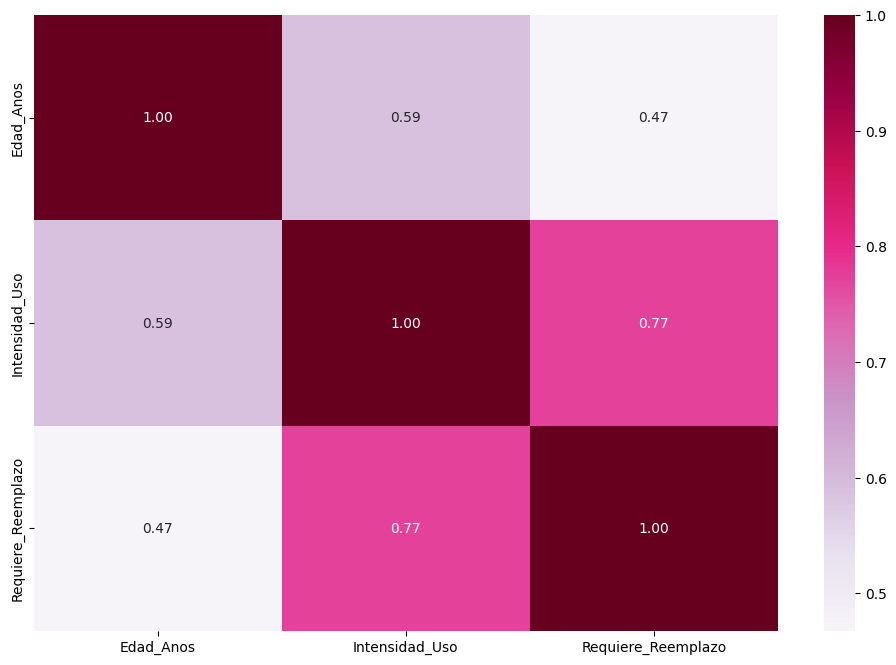

In [6]:
# Revisamos que correlación existe entre las variables

df_bateria.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(df_bateria.corr(numeric_only=True),
            annot=True,
            cmap="PuRd",
            fmt=".2f")

plt.show()

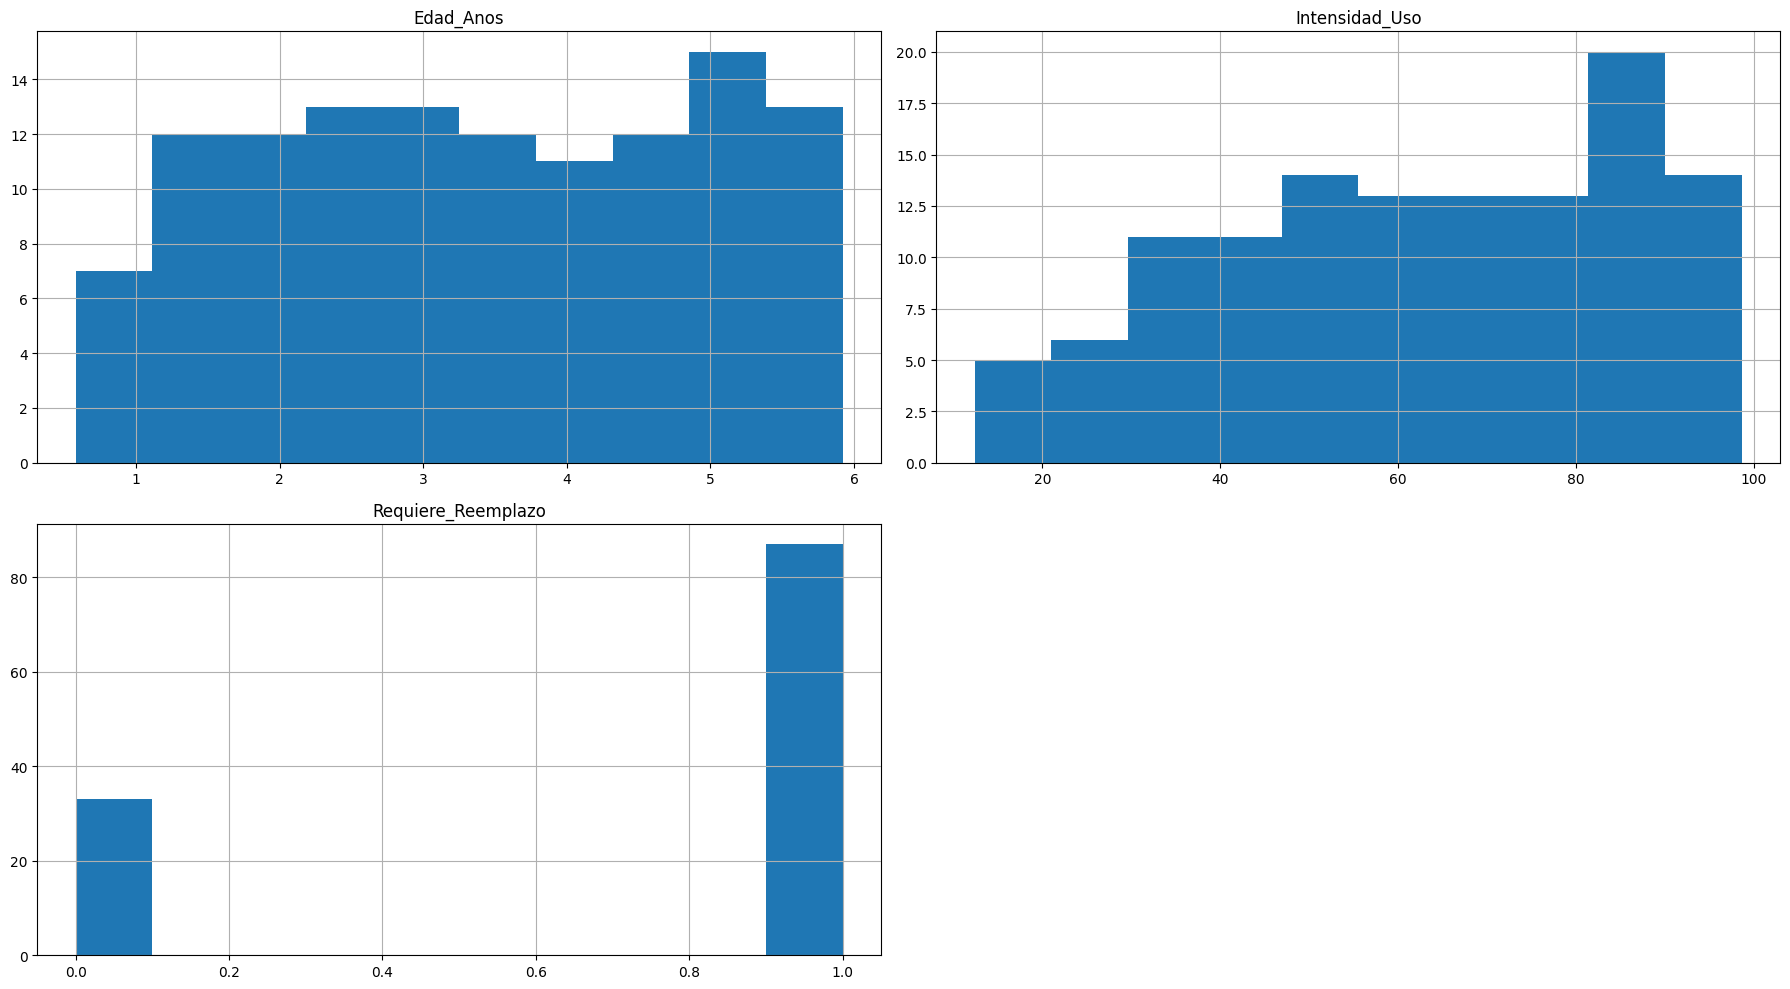

In [7]:
# Distribución de las variables

df_bateria.hist(figsize=(18, 10))

plt.tight_layout()
plt.show()

In [8]:
resumen = pd.DataFrame({
    "Cantidad": df_bateria["Requiere_Reemplazo"].value_counts().sort_index(),
    "Porcentaje (%)": (
        df_bateria["Requiere_Reemplazo"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

# Renombrar las clases
resumen.index = [
    "Está Sana (0)",
    "Necesita Reemplazo (1)"
]

print(resumen)

                        Cantidad  Porcentaje (%)
Está Sana (0)                 33            27.5
Necesita Reemplazo (1)        87            72.5


### Modelo SVC 



In [9]:
# Definición de los conjuntos de datos

X = df_bateria[["Edad_Anos","Intensidad_Uso"]]
y = df_bateria["Requiere_Reemplazo"]

In [10]:
# Separar Train-Test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.30, 
    stratify=y, # Para el desbalance de clases (mantiene la misma proporción siempre)
    random_state=42
)

### Proceso de normalización

In [11]:
# Estandarizar los valores
escalador = StandardScaler()

# Ajustar el escalador con el conjunto de entrenamiento
X_train_scaled = escalador.fit_transform(X_train)
X_test_scaled = escalador.transform(X_test)

### Construcción del modelo SVM - LINEAL

#### Cómo trabaja el modelo: 
- Tenemos Puntos rojos (baterías malas) y Puntos verdes (baterías sanas) en un plano. 
- SVM busca la línea que mejor separa ambos grupos con el mayor margen posible entre los puntos más cercanos a esa linea.
- Los puntos más cercanos a la frontera --> **vectores de soporte**

In [12]:
# Construcción del modelo
modelo_svm_bateria = SVC(kernel="linear", C=2.0, random_state=42)

modelo_svm_bateria.fit(X_train_scaled, y_train)


#kernel="linear" --> la frontera de decisión es una línea recta

,C,2.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


- **C alto** → el modelo intenta no cometer ningún error de entrenamiento, frontera más rígida, riesgo de sobreajuste
- **C bajo** → permite algunos errores a cambio de una frontera más suave y general

In [13]:
# Generar predicciones

y_pred = modelo_svm_bateria.predict(X_test_scaled)

In [14]:
print(classification_report(y_test, 
                            y_pred, 
                            target_names=["Está Sana (0)", 
                                          "Necesita Reemplazo (1)"])
    )


                        precision    recall  f1-score   support

         Está Sana (0)       0.90      0.90      0.90        10
Necesita Reemplazo (1)       0.96      0.96      0.96        26

              accuracy                           0.94        36
             macro avg       0.93      0.93      0.93        36
          weighted avg       0.94      0.94      0.94        36



### Conclusión
- **Precision**: el modelo acerto que el 90% estaban sanas y 96% que necesitan reemplazo. 
- **Recall**: de las realmente sanas, el modelo detecto 90%. De las que realmente necesitan reemplazo, detecto 96%
- **f1-score**: equilibrio entre ambas
- **Accuracy**: 94% de todas las predicciones fueron correctas. 

### Premisa más importante: El modelo falla un 4% en detectar una bateria dañada cuando me dice que esta sana. 

c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


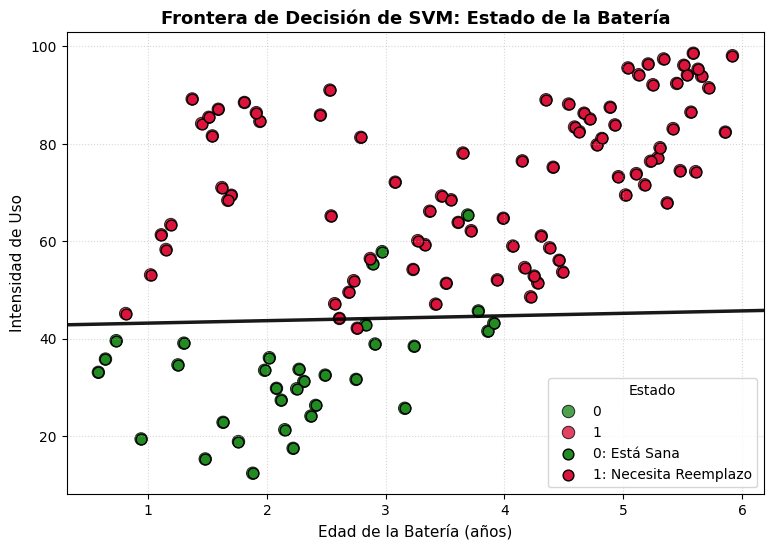

In [15]:
## Visualización del modelo

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_bateria,
    x="Edad_Anos",
    y="Intensidad_Uso",
    hue="Requiere_Reemplazo",
    palette={0: "forestgreen", 1: "crimson"},
    s=80,
    edgecolor="black",
    alpha=0.8
)

# Puntos de las baterías sanas
plt.scatter(
    df_bateria[df_bateria["Requiere_Reemplazo"] == 0]["Edad_Anos"],
    df_bateria[df_bateria["Requiere_Reemplazo"] == 0]["Intensidad_Uso"],
    color="forestgreen",
    label="0: Está Sana",
    s=60,
    edgecolors="black"
)

# Puntos de las baterías que necesitan reemplazo
plt.scatter(
    df_bateria[df_bateria["Requiere_Reemplazo"] == 1]["Edad_Anos"],
    df_bateria[df_bateria["Requiere_Reemplazo"] == 1]["Intensidad_Uso"],
    color="crimson",
    label="1: Necesita Reemplazo",
    s=60,
    edgecolors="black"
)

# Frontera de decisión del SVM

ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 200)
yy = np.linspace(ylim[0], ylim[1], 200)

YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Escalamos la malla
xy_scaled = escalador.transform(xy)

# Calculamos la función de decisión
Z = modelo_svm_bateria.decision_function(xy_scaled)
Z = Z.reshape(XX.shape)

# Dibujamos la frontera de decisión
ax.contour(
    XX,
    YY,
    Z,
    colors="black",
    levels=[0],
    alpha=0.9,
    linewidths=2.5
)

plt.title(
    "Frontera de Decisión de SVM: Estado de la Batería",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel(
    "Edad de la Batería (años)",
    fontsize=11
)

plt.ylabel(
    "Intensidad de Uso",
    fontsize=11
)

plt.legend(title="Estado")

plt.grid(True, linestyle=":", alpha=0.5)

plt.show()

### Modelo Poly 

In [35]:
# Construcción del modelo

modelo_svm_bateria = SVC(
    kernel="poly", 
    degree=2, 
    C=1.0, 
    gamma= "scale", 
    coef0=1, 
    random_state=42)

# Un C muy grande puede producir un sobreajuste. 

modelo_svm_bateria.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,1
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [36]:
y_pred_poly = modelo_svm_bateria.predict(X_test_scaled)
print(classification_report(y_test, y_pred_poly, 
    target_names=["Está Sana (0)", "Necesita Reemplazo (1)"]))

                        precision    recall  f1-score   support

         Está Sana (0)       0.90      0.90      0.90        10
Necesita Reemplazo (1)       0.96      0.96      0.96        26

              accuracy                           0.94        36
             macro avg       0.93      0.93      0.93        36
          weighted avg       0.94      0.94      0.94        36



c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


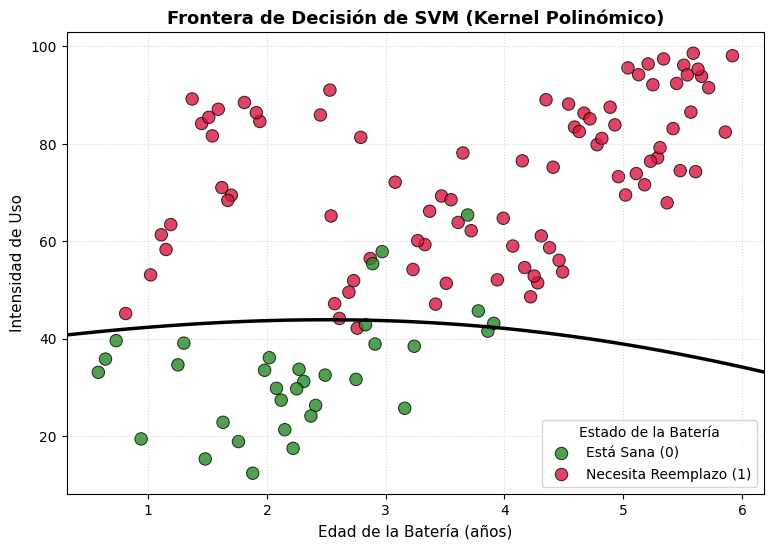

In [18]:
# ============================================
# Visualización del SVM (Kernel Polinómico)
# ============================================

# Creamos una copia del DataFrame para la visualización
df_grafico = df_bateria.copy()

# Cambiamos los valores 0 y 1 por etiquetas descriptivas
df_grafico["Estado"] = df_grafico["Requiere_Reemplazo"].map({
    0: "Está Sana (0)",
    1: "Necesita Reemplazo (1)"
})

plt.figure(figsize=(9, 6))

# Dibujamos los datos
sns.scatterplot(
    data=df_grafico,
    x="Edad_Anos",
    y="Intensidad_Uso",
    hue="Estado",
    hue_order=["Está Sana (0)", "Necesita Reemplazo (1)"],
    palette={
        "Está Sana (0)": "forestgreen",
        "Necesita Reemplazo (1)": "crimson"
    },
    s=80,
    edgecolor="black",
    alpha=0.8
)

# Obtenemos los límites del gráfico
ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Creamos una malla de puntos
xx = np.linspace(xlim[0], xlim[1], 300)
yy = np.linspace(ylim[0], ylim[1], 300)

XX, YY = np.meshgrid(xx, yy)

# Convertimos la malla en observaciones
xy = np.c_[XX.ravel(), YY.ravel()]

# Escalamos la malla
xy_scaled = escalador.transform(xy)

# Calculamos la función de decisión
Z = modelo_svm_bateria.decision_function(xy_scaled)
Z = Z.reshape(XX.shape)

# Dibujamos la frontera de decisión
ax.contour(
    XX,
    YY,
    Z,
    levels=[0],
    colors="black",
    linewidths=2.5
)

plt.title(
    "Frontera de Decisión de SVM (Kernel Polinómico)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel(
    "Edad de la Batería (años)",
    fontsize=11
)

plt.ylabel(
    "Intensidad de Uso",
    fontsize=11
)

plt.legend(title="Estado de la Batería")

plt.grid(True, linestyle=":", alpha=0.5)

plt.show()

### 3.3 Kernel Polinómico — Grado 3


In [31]:
modelo_poly3 = SVC(kernel="poly", degree=3, C=1.0, gamma="scale", coef0=1, random_state=42)
modelo_poly3.fit(X_train_scaled, y_train)

y_pred_poly3 = modelo_poly3.predict(X_test_scaled)

print(classification_report(
    y_test, y_pred_poly3,
    target_names=["Está Sana (0)", "Necesita Reemplazo (1)"]
))

                        precision    recall  f1-score   support

         Está Sana (0)       0.90      0.90      0.90        10
Necesita Reemplazo (1)       0.96      0.96      0.96        26

              accuracy                           0.94        36
             macro avg       0.93      0.93      0.93        36
          weighted avg       0.94      0.94      0.94        36



c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


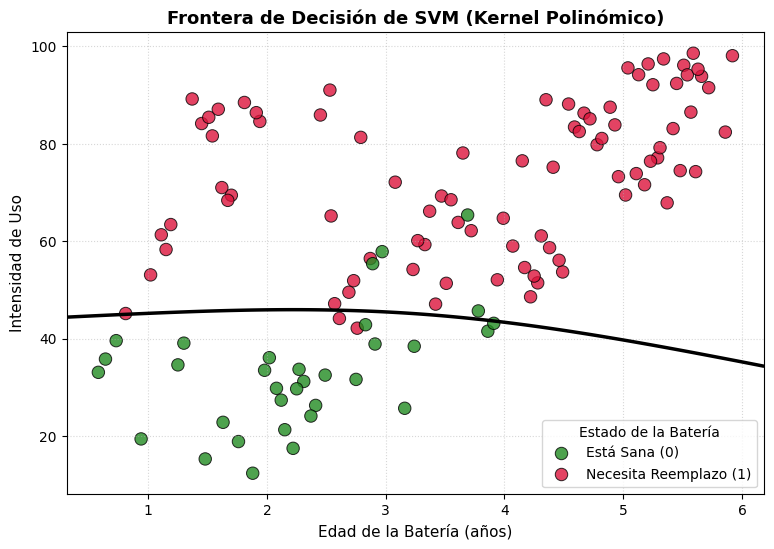

In [22]:
# ============================================
# Visualización del SVM (Kernel Polinómico)
# ============================================

# Creamos una copia del DataFrame para la visualización
df_grafico = df_bateria.copy()

# Cambiamos los valores 0 y 1 por etiquetas descriptivas
df_grafico["Estado"] = df_grafico["Requiere_Reemplazo"].map({
    0: "Está Sana (0)",
    1: "Necesita Reemplazo (1)"
})

plt.figure(figsize=(9, 6))

# Dibujamos los datos
sns.scatterplot(
    data=df_grafico,
    x="Edad_Anos",
    y="Intensidad_Uso",
    hue="Estado",
    hue_order=["Está Sana (0)", "Necesita Reemplazo (1)"],
    palette={
        "Está Sana (0)": "forestgreen",
        "Necesita Reemplazo (1)": "crimson"
    },
    s=80,
    edgecolor="black",
    alpha=0.8
)

# Obtenemos los límites del gráfico
ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Creamos una malla de puntos
xx = np.linspace(xlim[0], xlim[1], 300)
yy = np.linspace(ylim[0], ylim[1], 300)

XX, YY = np.meshgrid(xx, yy)

# Convertimos la malla en observaciones
xy = np.c_[XX.ravel(), YY.ravel()]

# Escalamos la malla
xy_scaled = escalador.transform(xy)

# Calculamos la función de decisión
Z = modelo_svm_bateria.decision_function(xy_scaled)
Z = Z.reshape(XX.shape)

# Dibujamos la frontera de decisión
ax.contour(
    XX,
    YY,
    Z,
    levels=[0],
    colors="black",
    linewidths=2.5
)

plt.title(
    "Frontera de Decisión de SVM (Kernel Polinómico)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel(
    "Edad de la Batería (años)",
    fontsize=11
)

plt.ylabel(
    "Intensidad de Uso",
    fontsize=11
)

plt.legend(title="Estado de la Batería")

plt.grid(True, linestyle=":", alpha=0.5)

plt.show()

c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


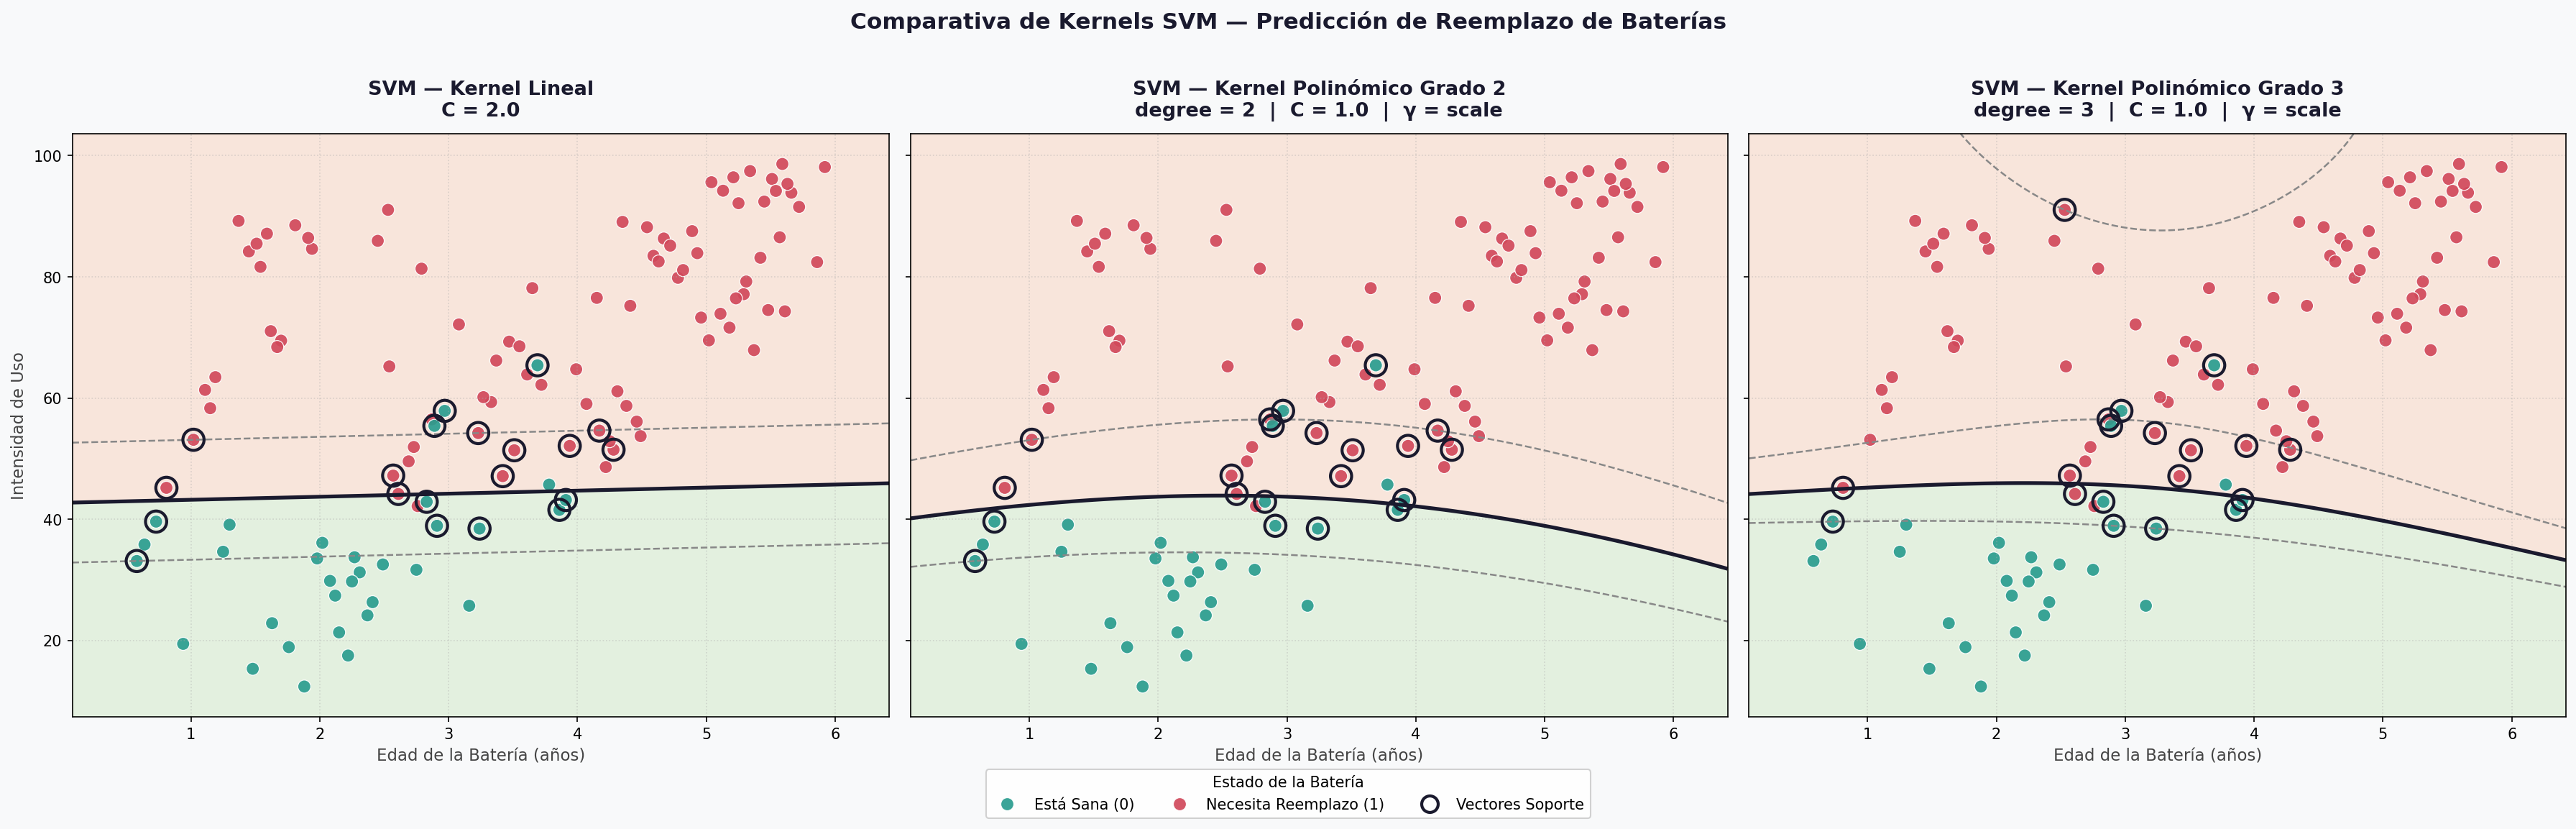

Vectores soporte  →  Lineal: 20  |  Poly-2: 21  |  Poly-3: 19


In [29]:
# ============================================================
# MALLA COMPARTIDA
# ============================================================

x_min = df_bateria["Edad_Anos"].min() - 0.5
x_max = df_bateria["Edad_Anos"].max() + 0.5
y_min = df_bateria["Intensidad_Uso"].min() - 5
y_max = df_bateria["Intensidad_Uso"].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)
grid        = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = escalador.transform(grid)

Z_lineal = modelo_lineal.predict(grid_scaled).reshape(xx.shape)
Z_poly2  = modelo_poly2.predict(grid_scaled).reshape(xx.shape)
Z_poly3  = modelo_poly3.predict(grid_scaled).reshape(xx.shape)

D_lineal = modelo_lineal.decision_function(grid_scaled).reshape(xx.shape)
D_poly2  = modelo_poly2.decision_function(grid_scaled).reshape(xx.shape)
D_poly3  = modelo_poly3.decision_function(grid_scaled).reshape(xx.shape)

sv_lineal = escalador.inverse_transform(modelo_lineal.support_vectors_)
sv_poly2  = escalador.inverse_transform(modelo_poly2.support_vectors_)
sv_poly3  = escalador.inverse_transform(modelo_poly3.support_vectors_)

df_plot = df_bateria.copy()
df_plot["Estado"] = df_plot["Requiere_Reemplazo"].map({
    0: "Está Sana (0)",
    1: "Necesita Reemplazo (1)"
})

PALETTE = {"Está Sana (0)": "#2A9D8F", "Necesita Reemplazo (1)": "#D1495B"}

# ============================================================
# FIGURA — 3 PANELES HORIZONTALES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(24, 7), dpi=150, sharey=True)
fig.patch.set_facecolor("#F8F9FA")

configs = [
    {"ax": axes[0], "Z": Z_lineal, "D": D_lineal, "sv": sv_lineal,
     "titulo": "SVM — Kernel Lineal",            "subtit": "C = 2.0"},
    {"ax": axes[1], "Z": Z_poly2,  "D": D_poly2,  "sv": sv_poly2,
     "titulo": "SVM — Kernel Polinómico Grado 2", "subtit": "degree = 2  |  C = 1.0  |  γ = scale"},
    {"ax": axes[2], "Z": Z_poly3,  "D": D_poly3,  "sv": sv_poly3,
     "titulo": "SVM — Kernel Polinómico Grado 3", "subtit": "degree = 3  |  C = 1.0  |  γ = scale"},
]

for cfg in configs:
    ax = cfg["ax"]
    ax.set_facecolor("#F8F9FA")

    ax.contourf(xx, yy, cfg["Z"], alpha=0.18, cmap="RdYlGn_r", levels=[-0.5, 0.5, 1.5])
    ax.contour(xx, yy, cfg["D"],
               levels=[-1, 0, 1],
               colors=["#888888", "#1A1A2E", "#888888"],
               linestyles=["--", "-", "--"],
               linewidths=[1.2, 2.5, 1.2])

    sns.scatterplot(data=df_plot, x="Edad_Anos", y="Intensidad_Uso",
                    hue="Estado", hue_order=list(PALETTE.keys()),
                    palette=PALETTE, s=75, edgecolor="white",
                    linewidth=0.6, alpha=0.92, ax=ax,
                    legend=(ax == axes[0]))

    ax.scatter(cfg["sv"][:, 0], cfg["sv"][:, 1],
               s=200, facecolors="none", edgecolors="#1A1A2E",
               linewidths=2.0, zorder=5)

    ax.set_title(f"{cfg['titulo']}\n{cfg['subtit']}",
                 fontsize=13, fontweight="bold", color="#1A1A2E", pad=12)
    ax.set_xlabel("Edad de la Batería (años)", fontsize=11, color="#444")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle=":", alpha=0.4, color="#AAAAAA")

axes[0].set_ylabel("Intensidad de Uso", fontsize=11, color="#444")
axes[1].set_ylabel("")
axes[2].set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()
sv_handle = Line2D([0], [0], marker="o", color="none",
                   markeredgecolor="#1A1A2E", markeredgewidth=2,
                   markersize=11, label="Vectores Soporte")
handles.append(sv_handle)
labels.append("Vectores Soporte")

fig.legend(handles, labels, title="Estado de la Batería",
           loc="lower center", ncol=3, fontsize=10, title_fontsize=10,
           frameon=True, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))

fig.suptitle("Comparativa de Kernels SVM — Predicción de Reemplazo de Baterías",
             fontsize=15, fontweight="bold", color="#1A1A2E", y=1.02)
plt.tight_layout()
plt.show()

print(f"Vectores soporte  →  Lineal: {len(sv_lineal)}  |  Poly-2: {len(sv_poly2)}  |  Poly-3: {len(sv_poly3)}")

In [30]:
modelos = {
    "Lineal  (C=2.0)":         (modelo_lineal, y_pred_lineal),
    "Poly Grado 2  (C=1.0)":   (modelo_poly2,  y_pred_poly2),
    "Poly Grado 3  (C=1.0)":   (modelo_poly3,  y_pred_poly3),
}

filas = []
for nombre, (modelo, y_pred) in modelos.items():
    r = classification_report(y_test, y_pred, output_dict=True)
    filas.append({
        "Modelo":                    nombre,
        "Precisión — Sana (0)":      round(r["0"]["precision"],   3),
        "Recall — Sana (0)":         round(r["0"]["recall"],       3),
        "F1 — Sana (0)":             round(r["0"]["f1-score"],     3),
        "Precisión — Reemplazo (1)": round(r["1"]["precision"],   3),
        "Recall — Reemplazo (1)":    round(r["1"]["recall"],       3),
        "F1 — Reemplazo (1)":        round(r["1"]["f1-score"],     3),
        "Accuracy":                  round(r["accuracy"],           3),
        "F1 Macro Avg":              round(r["macro avg"]["f1-score"], 3),
        "Vectores Soporte":          len(modelo.support_vectors_),
    })

df_comparativa = pd.DataFrame(filas).set_index("Modelo")
display(df_comparativa)

NameError: name 'y_pred_lineal' is not defined